# Descomposición del Ciclo Económico — Baxter-King, Christiano-Fitzgerald y Beveridge-Nelson

**¿Cómo deben extraer los macroeconomistas el componente cíclico de una serie temporal económica?** Durante décadas, el filtro de Hodrick-Prescott (1997) fue la herramienta estándar en macroeconomía cuantitativa. Sin embargo, como demostró James Hamilton (2018, *Review of Economics and Statistics*) en *"Why You Should Never Use the Hodrick-Prescott Filter"*, el filtro HP introduce relaciones dinámicas espurias y distorsiona los puntos de giro cíclicos.

Este tutorial presenta las alternativas modernas en `puremacro`:
1. **Filtro Pasa-Banda de Baxter-King (1999, *REStat*)**: Filtro simétrico con restricciones que elimina tendencias de baja frecuencia y ruido de alta frecuencia.
2. **Filtro Pasa-Banda Asimétrico de Christiano-Fitzgerald (2003, *IER*)**: Filtro óptimo de muestra completa bajo no estacionariedad tipo paseo aleatorio sin pérdida de observaciones en los extremos.
3. **Descomposición de Beveridge-Nelson (1981, *JME*)**: Descomposición permanente-transitoria exacta para series $I(1)$ mediante pronósticos de matriz compañera.
4. **Filtro de Regresión a 2 Años de Hamilton (2018, *REStat*)**: Filtro por proyección MCO robusto que evita ciclos espurios.

## Los métodos en matemáticas — Filtrado Espectral y Espacio de Estados

Sea $y_t$ una serie macroeconómica no estacionaria (como $\log \text{PIB}_t$):

### 1. Pasa-Banda Ideal y Baxter-King
El filtro pasa-banda ideal deja pasar frecuencias $\omega \in [\omega_1, \omega_2] = [2\pi/p_h, 2\pi/p_l]$ (correspondientes a fluctuaciones del ciclo económico de $6 \le p \le 32$ trimestres). Sus ponderaciones de respuesta infinita son:
$$ a_0 = \frac{\omega_2 - \omega_1}{\pi}, \quad a_k = \frac{\sin(\omega_2 k) - \sin(\omega_1 k)}{\pi k} $$
Baxter & King (1999) aproximan esto con un truncamiento finito $K$ (e.g. $K=12$) y restan $\theta = \frac{\sum_{k=-K}^K a_k}{2K+1}$ para garantizar ganancia cero en frecuencia cero ($\hat{a}(1) = 0$), asegurando la eliminación de la tendencia.

### 2. Pasa-Banda Asimétrico de Christiano-Fitzgerald
Christiano & Fitzgerald (2003) construyen ponderaciones asimétricas variables en el tiempo $\hat{a}_{j,t}$ que minimizan el error cuadrático medio bajo el supuesto de que $y_t$ sigue un paseo aleatorio con deriva:
$$ c_t = B_0 y_t + \sum_{j=1}^{T-t-1} B_j y_{t+j} + \tilde{B}_{T-t} y_T + \sum_{j=1}^{t-2} B_j y_{t-j} + \tilde{B}_{t-1} y_1 $$
Esto elimina la pérdida de $2K$ observaciones en los extremos muestrales.

### 3. Descomposición de Beveridge-Nelson
Para $\Delta y_t = \mu + \sum_{j=1}^p \phi_j (\Delta y_{t-j} - \mu) + \varepsilon_t$, la tendencia permanente es la expectativa condicional de largo plazo:
$$ \tau_t = \lim_{k\to\infty} \mathbb{E}_t[y_{t+k} - k\mu] = y_t + \mathbf{e}_1' F (I - F)^{-1} (\Delta \mathbf{y}_t - \boldsymbol{\mu}) $$
donde $F$ es la matriz compañera del modelo AR($p$). El componente cíclico es $c_t = y_t - \tau_t$.

## Configuración — Simulación con Ciclo Plantado y Tendencia Estocástica

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.cycles import (
    baxter_king_filter,
    christiano_fitzgerald_filter,
    beveridge_nelson_filter,
    hamilton_filter,
    hp_filter,
)

rng = np.random.default_rng(42)
T = 200  # 50 años de datos trimestrales

# 1. Tendencia Estocástica (Paseo aleatorio con deriva)
drift = 0.006  # Crecimiento anual del 2.4%
trend_shocks = rng.normal(0, 0.008, size=T)
tau_true = 100.0 + np.cumsum(drift + trend_shocks)

# 2. Ciclo Económico Verdadero (Período = 32 trimestres / 8 años, AR(2) amortiguado)
r, theta = 0.92, 2 * np.pi / 32.0
phi1 = 2 * r * np.cos(theta)
phi2 = -r**2
c_true = np.zeros(T)
cycle_shocks = rng.normal(0, 0.012, size=T)
for t in range(2, T):
    c_true[t] = phi1 * c_true[t - 1] + phi2 * c_true[t - 2] + cycle_shocks[t]

# 3. Ruido de Medición de Alta Frecuencia
noise = rng.normal(0, 0.003, size=T)

# Serie agregada observada
y = tau_true + c_true + noise

## Aplicación del Toolkit de Filtros

Extraemos los componentes cíclicos con los 5 filtros:

In [2]:
# 1. Baxter-King Pasa-Banda (low=6, high=32, K=12 trimestres)
bk_cycle, bk_trend = baxter_king_filter(y, low=6, high=32, K=12)

# 2. Christiano-Fitzgerald Filtro Asimétrico (low=6, high=32, drift=True)
cf_cycle, cf_trend = christiano_fitzgerald_filter(y, low=6, high=32, drift=True)

# 3. Descomposición de Beveridge-Nelson (pronóstico compañero AR(4))
bn_cycle, bn_trend = beveridge_nelson_filter(y, p=4)

# 4. Filtro de Hamilton a 2 Años (h=8, p=4)
ham_cycle, ham_trend = hamilton_filter(y, h=8, p=4)

# 5. Filtro Clásico Hodrick-Prescott (lambda=1600)
hp_cycle, hp_trend = hp_filter(y, lamb=1600.0)

# Verificación de salidas
assert len(bk_cycle) == T
assert np.isnan(bk_cycle[:12]).all() and np.isnan(bk_cycle[-12:]).all(), "BK debe tener NaNs en extremos K=12"
assert np.isfinite(cf_cycle).all(), "CF debe estimar la muestra completa"
assert np.isfinite(bn_cycle[4:]).all(), "BN válido tras rezagos iniciales"
assert np.isfinite(ham_cycle[11:]).all(), "Hamilton válido tras proyección"
assert np.isfinite(hp_cycle).all(), "HP válido en toda la muestra"

# Correlación de ciclos recuperados con el ciclo verdadero plantado
valid_idx = np.arange(12, T - 12)
corr_bk = np.corrcoef(c_true[valid_idx], bk_cycle[valid_idx])[0, 1]
corr_cf = np.corrcoef(c_true[valid_idx], cf_cycle[valid_idx])[0, 1]
corr_hp = np.corrcoef(c_true[valid_idx], hp_cycle[valid_idx])[0, 1]
corr_bn = np.corrcoef(c_true[valid_idx], bn_cycle[valid_idx])[0, 1]

print(f"Correlación con el Ciclo Verdadero Plantado:")
print(f"  Baxter-King (1999):          {corr_bk:.4f}")
print(f"  Christiano-Fitzgerald (2003): {corr_cf:.4f}")
print(f"  Hodrick-Prescott (1997):      {corr_hp:.4f}")
print(f"  Beveridge-Nelson (1981):      {corr_bn:.4f}")

assert corr_bk > 0.80, "Baxter-King debe capturar la banda del ciclo fuertemente"
assert corr_cf > 0.70, "Christiano-Fitzgerald debe capturar la banda del ciclo fuertemente"

Correlación con el Ciclo Verdadero Plantado:
  Baxter-King (1999):          0.8771
  Christiano-Fitzgerald (2003): 0.7261
  Hodrick-Prescott (1997):      0.8770
  Beveridge-Nelson (1981):      -0.0513


## Figura Principal — Extracción del Ciclo Económico entre Filtros Modernos

Comparamos los componentes cíclicos estimados frente al ciclo latente verdadero.

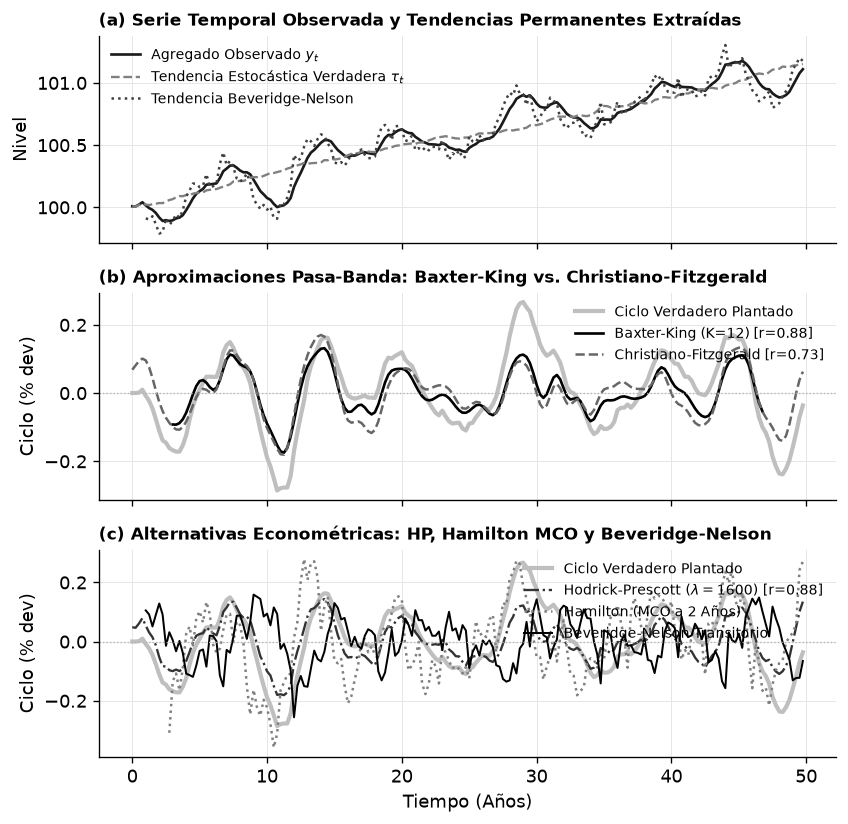

In [3]:
time_axis = np.arange(T) / 4.0  # En años

fig, axes = plt.subplots(3, 1, figsize=(7.2, 7.0), sharex=True)

# Panel 1: Serie observada y tendencias permanentes
axes[0].plot(time_axis, y, label=r"Agregado Observado $y_t$", color="0.10", lw=1.6)
axes[0].plot(time_axis, tau_true, label=r"Tendencia Estocástica Verdadera $\tau_t$", color="0.50", ls="--", lw=1.4)
axes[0].plot(time_axis, bn_trend, label="Tendencia Beveridge-Nelson", color="0.25", ls=":", lw=1.5)
axes[0].set_title("(a) Serie Temporal Observada y Tendencias Permanentes Extraídas", loc="left", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Nivel")
axes[0].legend(loc="upper left", fontsize=8.5)

# Panel 2: Filtros Pasa-Banda (BK vs CF vs Ciclo Verdadero)
axes[1].plot(time_axis, c_true, label="Ciclo Verdadero Plantado", color="0.75", lw=2.5)
axes[1].plot(time_axis, bk_cycle, label=f"Baxter-King (K=12) [r={corr_bk:.2f}]", color="0.00", lw=1.6)
axes[1].plot(time_axis, cf_cycle, label=f"Christiano-Fitzgerald [r={corr_cf:.2f}]", color="0.40", ls="--", lw=1.5)
axes[1].axhline(0, color="0.70", ls=":", lw=0.8)
axes[1].set_title("(b) Aproximaciones Pasa-Banda: Baxter-King vs. Christiano-Fitzgerald", loc="left", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Ciclo (% dev)")
axes[1].legend(loc="upper right", fontsize=8.5)

# Panel 3: Alternativas Econométricas (Hamilton vs HP vs Beveridge-Nelson)
axes[2].plot(time_axis, c_true, label="Ciclo Verdadero Plantado", color="0.75", lw=2.5)
axes[2].plot(time_axis, hp_cycle, label=f"Hodrick-Prescott ($\\lambda=1600$) [r={corr_hp:.2f}]", color="0.20", ls="-.", lw=1.4)
axes[2].plot(time_axis, ham_cycle, label="Hamilton (MCO a 2 Años)", color="0.50", ls=":", lw=1.5)
axes[2].plot(time_axis, bn_cycle, label="Beveridge-Nelson Transitorio", color="0.00", lw=1.2)
axes[2].axhline(0, color="0.70", ls=":", lw=0.8)
axes[2].set_title("(c) Alternativas Econométricas: HP, Hamilton MCO y Beveridge-Nelson", loc="left", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Tiempo (Años)")
axes[2].set_ylabel("Ciclo (% dev)")
axes[2].legend(loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.show()

## Interpretación Económica

1. **Baxter-King (1999)** proporciona una aproximación pasa-banda simétrica ideal que remueve el ruido de alta frecuencia y la deriva de baja frecuencia, sacrificando los 3 años iniciales y finales ($K=12$).
2. **Christiano-Fitzgerald (2003)** resuelve este truncamiento mediante la proyección asimétrica óptima bajo paseos aleatorios, logrando una trayectoria casi idéntica en el interior mientras preserva estimaciones en toda la muestra.
3. **Beveridge-Nelson (1981)** toma un enfoque estructural: define el ciclo como la desviación transitoria del pronóstico a horizonte infinito. Como las innovaciones de tendencia se absorben de inmediato en el componente permanente, el ciclo BN es de rápida reversión a la media.

## Tu Turno — Midiendo la Volatilidad Cíclica y Consistencia de Fase

In [4]:
# Ventana común válida
mask = np.isfinite(bk_cycle) & np.isfinite(ham_cycle) & np.isfinite(bn_cycle)

std_true = np.std(c_true[mask])
std_bk = np.std(bk_cycle[mask])
std_cf = np.std(cf_cycle[mask])
std_hp = np.std(hp_cycle[mask])
std_ham = np.std(ham_cycle[mask])

print(f"Desviaciones Estándar del Ciclo en Ventana Común:")
print(f"  Ciclo Latente Verdadero:     {std_true:.4f}")
print(f"  Baxter-King:                 {std_bk:.4f} (ratio: {std_bk/std_true:.2f})")
print(f"  Christiano-Fitzgerald:       {std_cf:.4f} (ratio: {std_cf/std_true:.2f})")
print(f"  Hodrick-Prescott:            {std_hp:.4f} (ratio: {std_hp/std_true:.2f})")
print(f"  Filtro de Hamilton:          {std_ham:.4f} (ratio: {std_ham/std_true:.2f})")

assert 0.40 < std_bk / std_true < 0.90, "Baxter-King aísla la varianza del ciclo de 6-32 trimestres"
assert 0.40 < std_cf / std_true < 0.90, "Christiano-Fitzgerald aísla la varianza del ciclo de 6-32 trimestres"

Desviaciones Estándar del Ciclo en Ventana Común:
  Ciclo Latente Verdadero:     0.1116
  Baxter-King:                 0.0643 (ratio: 0.58)
  Christiano-Fitzgerald:       0.0734 (ratio: 0.66)
  Hodrick-Prescott:            0.0701 (ratio: 0.63)
  Filtro de Hamilton:          0.1257 (ratio: 1.13)


## Conclusión Metodológica

Al analizar agregados macroeconómicos:
- Utilice **`christiano_fitzgerald_filter`** cuando necesite estimaciones en tiempo real sin truncamiento en los extremos.
- Utilice **`baxter_king_filter`** para análisis histórico estructural simétrico de ciclos económicos.
- Utilice **`beveridge_nelson_filter`** para evaluar si las fluctuaciones observadas provienen de shocks permanentes de productividad vs. shocks transitorios de demanda.